Sequence A:

AGCTTGCAGCGTCCGTTAGCTCGAGTCCAGGACGTTAGTCCTGCAGTC

Sequence B:

CAGTAAGTTGCCGTTAGCGCGTAGTGCCAGTAAGCGGCTCGTTAGTGG

Please use Biopython to:
- Determine the molecular weight of both sequence.
- Refer to the Wallace rule to calculate the melting point of sequence A and sequence B and plot them using Matplotlib library.
- Calculate the GC content of sequence A and sequence B.
- Calculate the AT content of sequence A and sequence B.
- Plot the GC and AT content of sequence A and sequence B using Matplotlib library.





In [25]:
%pip install BioPython
import Bio
from Bio.Seq import Seq

# Make the DNA Sequence
Seq_A = Seq("AGCTTGCAGCGTCCGTTAGCTCGAGTCCAGGACGTTAGTCCTGCAGTC")
Seq_B = Seq("CAGTAAGTTGCCGTTAGCGCGTAGTGCCAGTAAGCGGCTCGTTAGTGG")

Note: you may need to restart the kernel to use updated packages.


Determine the molecular weight of both sequence.

In [4]:
from Bio.SeqUtils import molecular_weight
# Sequence A
print(molecular_weight(Seq_A, seq_type='DNA'))

# Sequence B
print(molecular_weight(Seq_B, seq_type='DNA'))

14831.413499999999
14975.5105


Melting point using the walace rule

In [13]:
from Bio.SeqUtils import MeltingTemp as mt

# built in 
print(mt.Tm_Wallace(Seq_A))
print(mt.Tm_Wallace(Seq_B))


152.0
150.0


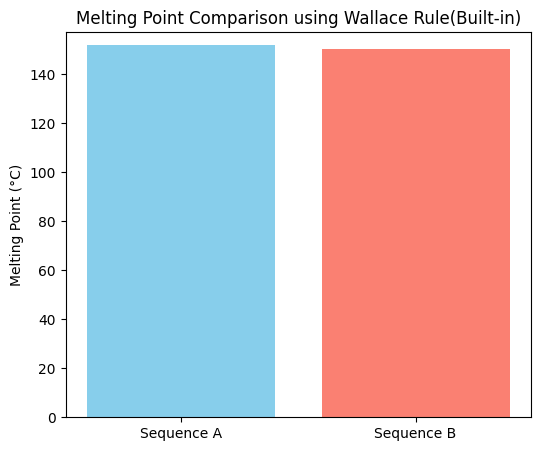

In [16]:
sequences = ['Sequence A', 'Sequence B']
tm_values = [mt.Tm_Wallace(Seq_A), mt.Tm_Wallace(Seq_B)] 

# Create a bar chart
plt.figure(figsize=(6, 5))
plt.bar(sequences, tm_values, color=['skyblue', 'salmon'])
plt.ylabel('Melting Point (°C)')
plt.title('Melting Point Comparison using Wallace Rule(Built-in)')
plt.ylim(0, max(tm_values) + 5)
plt.show()

In [ ]:
# own function
def own_wallace_mt(dna):
    jumA = dna.count('A')
    jumT = dna.count('T')
    jumG = dna.count('G')
    jumC = dna.count('C')
    # len(seq) == jumlahA + jumlahT + jumlahG + jumlahC
    if len(dna) < 14:
        Tm = 2*(jumA + jumT) + 4*(jumG + jumC)
    elif len(dna) >= 14:
        Tm = round(64.9 + 41*(jumG + jumC - 16.4)/len(dna), 2)
    return Tm

print(own_wallace_mt(Seq_A))
print(own_wallace_mt(Seq_B))

74.81
73.95


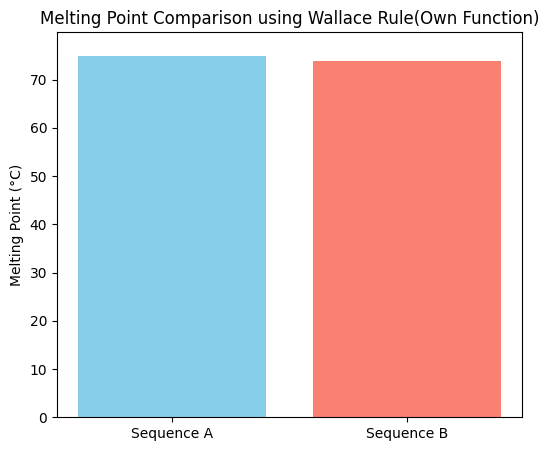

In [17]:
import matplotlib.pyplot as plt

# Example sequences: (replace with your actual sequences)
# Seq A = "ATGC" (2 A/T, 2 G/C) -> Tm = 2(2) + 4(2) = 12°C
# Seq B = "GCGC" (0 A/T, 4 G/C) -> Tm = 2(0) + 4(4) = 16°C
sequences = ['Sequence A', 'Sequence B']
tm_values = [own_wallace_mt(Seq_A), own_wallace_mt(Seq_B)] 

# Create a bar chart
plt.figure(figsize=(6, 5))
plt.bar(sequences, tm_values, color=['skyblue', 'salmon'])
plt.ylabel('Melting Point (°C)')
plt.title('Melting Point Comparison using Wallace Rule(Own Function)')
plt.ylim(0, max(tm_values) + 5)
plt.show()




Calculate the GC content of sequence A and sequence B

In [18]:
from Bio.SeqUtils import gc_fraction
seqA_GC = gc_fraction(Seq_A)
seqB_GC = gc_fraction(Seq_B)
print(f"GC fraction of Sequence A: {seqA_GC:.2%}")
print(f"GC fraction of Sequence B: {seqB_GC:.2%}")

GC fraction of Sequence A: 58.33%
GC fraction of Sequence B: 56.25%


Calculate the AT content of sequence A and sequence B

In [19]:
seqA_AT = 1 - gc_fraction(Seq_A)
seqB_AT = 1 - gc_fraction(Seq_B)

print(f"AT fraction of Sequence A: {seqA_AT:.2%}")
print(f"AT fraction of Sequence B: {seqB_AT:.2%}")

AT fraction of Sequence A: 41.67%
AT fraction of Sequence B: 43.75%


Plot the GC and AT content of sequence A and sequence B using Matplotlib library

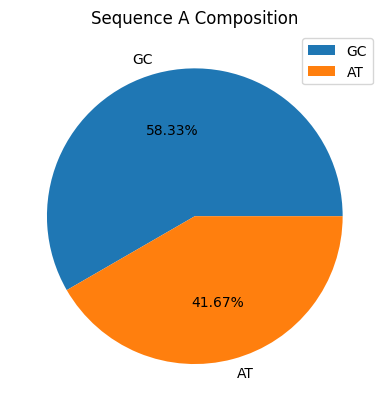

In [22]:
# Plot Sequence A
plt.pie([seqA_GC, seqA_AT], labels=['GC', 'AT'], autopct='%1.2f%%')
plt.title('Sequence A Composition')
plt.legend(["GC", "AT"])
plt.show()

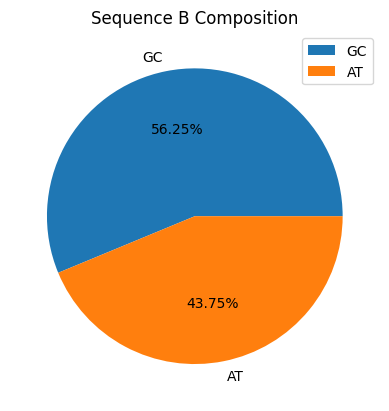

In [23]:
# Plot Sequence B
plt.pie([seqB_GC, seqB_AT], labels=['GC', 'AT'], autopct='%1.2f%%')
plt.title('Sequence B Composition')
plt.legend(["GC", "AT"])
plt.show()